In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import torch

In [48]:
# load the dataset
original_dataset = pd.read_csv("../data/Churn_Modelling.csv")
df = original_dataset.copy()

In [49]:
# overview of the dataset
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [51]:
# check the null values in the data
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [52]:
# check the duplicates
df.duplicated().sum()

np.int64(0)

In [53]:
# separate the categorical and numerical cols
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns
print(f"Categorical cols: ",categorical_cols)
print(f"Numerical cols: ", numerical_cols)

Categorical cols:  Index(['Surname', 'Geography', 'Gender'], dtype='object')
Numerical cols:  Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


<Axes: xlabel='Geography'>

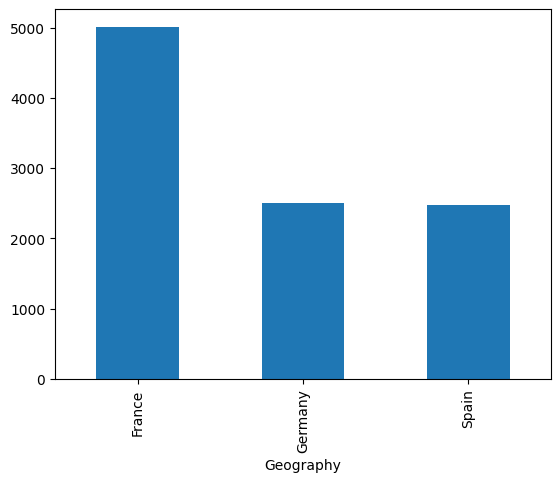

In [54]:
df['Geography'].value_counts().plot(kind='bar')

In [55]:
# check the numbers of exited and remained customers in company
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [56]:
# This shows the imbalanced dataset

In [57]:
# check the col: gender
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [58]:
# This seems pretty balanced col

In [59]:
# drop the unnecessary cols
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [60]:
# change categorical cols to numerical using onehot encoding
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True).astype('int')

In [61]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


In [62]:
# separate dependent and independent cols
X = df.drop(columns=['Exited'])
y = df['Exited']

In [63]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [64]:
# check the size of train and test data
print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [85]:
# scale the dataset 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [87]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [101]:
model = Sequential()
# to improve the accuracy of the model, we add more nodes
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(1, activation='sigmoid'))

In [102]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [107]:
history = model.fit(X_train_scaled,y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.8675 - loss: 0.3194 - val_accuracy: 0.8506 - val_loss: 0.3487
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.8681 - loss: 0.3190 - val_accuracy: 0.8525 - val_loss: 0.3484
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - accuracy: 0.8661 - loss: 0.3189 - val_accuracy: 0.8525 - val_loss: 0.3480
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.8681 - loss: 0.3190 - val_accuracy: 0.8537 - val_loss: 0.3486
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8689 - loss: 0.3188 - val_accuracy: 0.8494 - val_loss: 0.3495
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.8678 - loss: 0.3190 - val_accuracy: 0.8525 - val_loss: 0.3488
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - accuracy: 0.8675 - loss: 0.3190 - val_accuracy: 0.8500 - val_loss: 0.3498
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - accuracy: 0.8672 - loss: 0

In [108]:
# get the weights calculated
model.layers[0].get_weights()

[array([[ 0.25745746, -0.18920495, -0.05312249, -0.02142483,  0.27824375,
         -0.20557581, -0.92216957,  0.15454222,  0.6662216 ,  0.12385799,
          0.33779445],
        [-0.6464541 , -0.49749348,  0.06968337,  0.6060374 , -0.30210796,
          1.7931823 , -0.29281756,  0.12286856, -0.37464696,  0.07016813,
         -0.5069768 ],
        [ 0.04153318,  0.44103715, -0.19832559,  0.4271663 ,  0.09461088,
         -0.12414239,  0.06376575,  0.12012692, -0.16615276,  0.1025397 ,
          0.25286722],
        [ 0.63785225, -0.7561634 , -0.5157337 ,  0.17245398,  0.05488186,
         -0.55796146, -0.5352102 , -0.20117924, -0.35207653,  0.4876836 ,
         -0.3074555 ],
        [-0.5795834 ,  0.28213367, -0.15354183, -0.02616409, -0.04407904,
         -0.26757994,  0.15298012, -1.200146  , -0.12903021,  1.0327874 ,
          0.14560995],
        [ 0.31524372,  0.07339009, -0.2777592 ,  0.39237556, -0.14744207,
         -0.29414508, -0.11082723,  0.08662257,  1.0877628 , -0.0855949

In [109]:
model.layers[1].get_weights()

[array([[-0.9502381 , -1.0562742 ,  0.17087   , -0.24053153,  0.18068849,
         -0.46741804, -0.1211939 ,  0.3608731 , -0.08194397,  0.16342041,
         -0.10814045],
        [ 0.02116425,  0.4446739 ,  0.5471824 , -0.73811597,  0.7161332 ,
          0.2661097 ,  0.39336425,  0.40484175,  0.305882  , -0.43733323,
         -0.5504135 ],
        [ 0.23002337, -0.07972363, -0.82344264,  0.0969659 ,  0.68444145,
          0.24130721,  0.2047461 ,  0.51276237,  0.32702264, -1.1657381 ,
          0.2820793 ],
        [ 0.41410732,  0.41248798, -0.27832142, -0.37468266, -0.13495709,
          0.03887074, -0.7585471 ,  0.29120752, -0.03881827,  0.766222  ,
          0.6044726 ],
        [-0.29050022, -0.5645087 , -0.36680585, -0.34161478, -0.6734757 ,
         -0.5522101 , -0.36416164,  0.43266597,  0.7023702 ,  0.68845606,
         -1.2945005 ],
        [-0.24513635, -0.31250754,  0.35196793,  0.638672  ,  0.52841234,
         -0.18121247,  0.07897572,  0.3752335 , -0.8751039 , -0.3495915

In [110]:
# predict

y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step


In [111]:
# since sigmoid is used as a activation function, the output is between 0 and 1

In [112]:
# set a threshold for an output in a specific range
y_pred = np.where(y_log>0.5,1,0)

In [113]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.859

In [114]:
# plot a graph
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.8675000071525574,
  0.8681250214576721,
  0.8660937547683716,
  0.8681250214576721,
  0.8689062595367432,
  0.8678125143051147,
  0.8675000071525574,
  0.8671875,
  0.8684375286102295,
  0.8673437237739563,
  0.8692187666893005,
  0.8696874976158142,
  0.8693749904632568,
  0.8675000071525574,
  0.8676562309265137,
  0.8660937547683716,
  0.8660937547683716,
  0.8696874976158142,
  0.8684375286102295,
  0.8675000071525574,
  0.8684375286102295,
  0.866406261920929,
  0.8681250214576721,
  0.8673437237739563,
  0.8690624833106995,
  0.8698437213897705,
  0.8695312738418579,
  0.8689062595367432,
  0.8700000047683716,
  0.8698437213897705,
  0.8684375286102295,
  0.8681250214576721,
  0.8696874976158142,
  0.8706250190734863,
  0.870312511920929,
  0.8687499761581421,
  0.8689062595367432,
  0.8681250214576721,
  0.8687499761581421,
  0.8700000047683716,
  0.8701562285423279,
  0.8706250190734863,
  0.867968738079071,
  0.8696874976158142,
  0.8690624833106995,
  0.869531

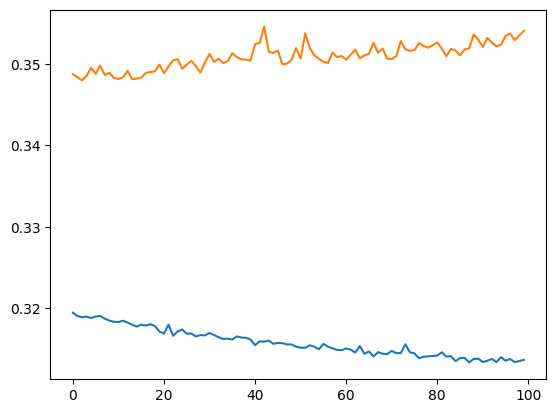

In [116]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

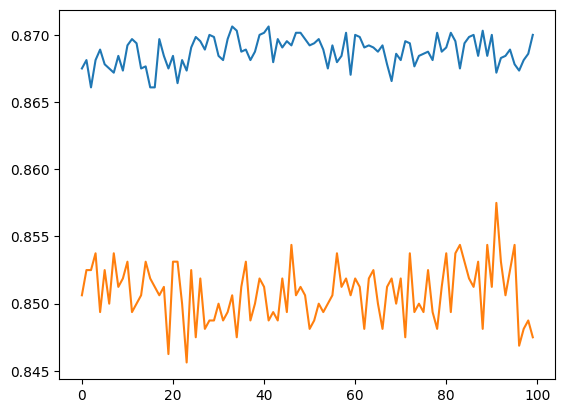

In [117]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])